<a href="https://colab.research.google.com/github/JonathanDLCH/Crypto_DataAnalysis/blob/main/1_Python_para_Crypto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 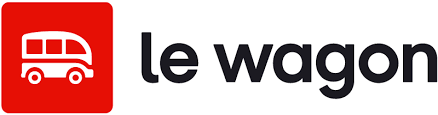

# Semana 1 - Sesión 1: Python para Crypto

---

## Objetivos de Aprendizaje

Al finalizar esta sesión serás capaz de:

- Utilizar Google Colab/Jupyter Notebooks para ejecutar código Python de forma interactiva
- Aplicar los conceptos fundamentales de Python (tipos de datos, estructuras, loops)
- Conectarte a una API de criptomonedas y obtener datos en tiempo real
- Obtener el precio actual de BTC, ETH y SOL
- Transformar datos de API en DataFrames de Pandas

## Conceptos Clave

- **API (Application Programming Interface)**: Interfaz que permite comunicación entre aplicaciones
- **JSON**: Formato de datos ligero para intercambio de información
- **DataFrame**: Estructura tabular de Pandas para análisis de datos
- **OHLC**: Open, High, Low, Close - datos de velas japonesas

---

## 1. Introducción a Google Colab

El documento que estás leyendo no es una página web estática, sino un entorno interactivo denominado **cuaderno de Colab** (o Jupyter Notebook) que te permite escribir y ejecutar código.

### ¿Qué es un Notebook?

Un notebook combina:
- **Celdas de código** ejecutable
- **Celdas de texto** con formato (Markdown)
- **Visualizaciones** y gráficos

### ¿Cómo ejecutar código?

1. Haz clic en la celda para seleccionarla
2. Presiona el botón ▶️ o usa `Ctrl + Enter`

Probemos con un ejemplo simple:

In [ ]:
# Calculate seconds in a day
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

Las variables definidas en una celda pueden usarse en otras celdas:

In [ ]:
# Use the variable from the previous cell
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

---

## 2. Repaso de Python

Antes de trabajar con APIs de crypto, repasemos los conceptos fundamentales de Python.

### 2.1 Tipos de Datos Básicos

#### Números Enteros (int)

In [ ]:
# Integer examples
btc_supply = 21000000
current_block = 800000

print(f"Bitcoin max supply: {btc_supply}")
print(f"Current block: {current_block}")

Bitcoin max supply: 21000000
Current block: 800000


#### Números Decimales (float)

In [ ]:
# Float examples
btc_price = 97290.50
eth_price = 3371.32

print(f"BTC price: ${btc_price}")
print(f"ETH price: ${eth_price}")

BTC price: $97290.5
ETH price: $3371.32


#### Cadenas de Texto (str)

In [ ]:
# String examples
symbol = 'BTCUSDC'
blockchain = 'Ethereum'

print(f"Trading pair: {symbol}")
print(f"Blockchain: {blockchain}")

Trading pair: BTCUSDC
Blockchain: Ethereum


#### Booleanos (bool)

In [ ]:
# Boolean examples
is_bullish = True
is_bearish = False

print(f"Market is bullish: {is_bullish}")
print(f"Market is bearish: {is_bearish}")

Market is bullish: True
Market is bearish: False


### 2.2 Estructuras de Datos

#### Listas (list)

Las listas son colecciones ordenadas y modificables.

In [ ]:
# List of cryptocurrencies
top_cryptos = ['bitcoin', 'ethereum', 'solana', 'binancecoin']
print(f"Top cryptos: {top_cryptos}")

# Access elements by index
print(f"First crypto: {top_cryptos[0]}")
print(f"Last crypto: {top_cryptos[-1]}")

Top cryptos: ['bitcoin', 'ethereum', 'solana', 'binancecoin']
First crypto: bitcoin
Last crypto: binancecoin


#### Diccionarios (dict)

Los diccionarios almacenan pares clave-valor. Son fundamentales para trabajar con datos de APIs.

In [ ]:
# Dictionary with crypto prices
crypto_prices = {
    'bitcoin': 97290,
    'ethereum': 3371.32,
    'solana': 146.75
}

print(f"BTC price: ${crypto_prices['bitcoin']}")
print(f"ETH price: ${crypto_prices['ethereum']}")

BTC price: $97290
ETH price: $3371.32


In [ ]:
# OHLC data as dictionary (common format in crypto APIs)
btc_candle = {
    'open': 97000.0,
    'high': 98500.0,
    'low': 96800.0,
    'close': 97290.0,
    'volume': 15000000000
}

print(f"BTC opened at: ${btc_candle['open']}")
print(f"BTC closed at: ${btc_candle['close']}")

BTC opened at: $97000.0
BTC closed at: $97290.0


### 2.3 Loops (Ciclos)

Los loops nos permiten iterar sobre colecciones de datos.

In [ ]:
# Iterate over a list
for crypto in top_cryptos:
    print(f"Crypto: {crypto}")

Crypto: bitcoin
Crypto: ethereum
Crypto: solana
Crypto: binancecoin


In [ ]:
# Iterate over dictionary items
for coin, price in crypto_prices.items():
    print(f"{coin.capitalize()}: ${price:,.2f}")

Bitcoin: $97,290.00
Ethereum: $3,371.32
Solana: $146.75


---

## 3. Librerías Esenciales

Python tiene un ecosistema rico de librerías. Para este curso usaremos principalmente:

| Librería | Uso |
|----------|-----|
| `pandas` | Manipulación de datos tabulares |
| `requests` | Llamadas HTTP a APIs |
| `matplotlib` | Visualizaciones básicas |
| `plotly` | Visualizaciones interactivas |
| `pycoingecko` | Cliente de API de CoinGecko |

---

## 4. Setup del Entorno

Instalamos e importamos las librerías necesarias.

In [ ]:
# Install pycoingecko library
!pip install pycoingecko -q

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# HTTP requests
import requests

# API client
from pycoingecko import CoinGeckoAPI

# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


---

## 5. Introducción a las APIs

### ¿Qué es una API?

Una **API** (Application Programming Interface) es una interfaz que permite que diferentes aplicaciones se comuniquen entre sí. En el contexto de criptomonedas, las APIs nos permiten:

- Obtener precios en tiempo real
- Acceder a datos históricos
- Ejecutar operaciones de trading (con APIs autenticadas)

### CoinGecko API

CoinGecko es una de las APIs de crypto más populares porque:
- Es **gratuita** para uso básico
- No requiere autenticación para datos públicos
- Ofrece datos de miles de criptomonedas
- Tiene una librería de Python (`pycoingecko`) fácil de usar

### Dos Enfoques para Trabajar con APIs

Existen dos formas principales de interactuar con APIs:

1. **Solicitudes HTTP directas (endpoints)**: Usando la librería `requests` para hacer llamadas directas a las URLs de la API. Este enfoque te da control total y funciona con cualquier API.

2. **Librerías cliente**: Usando paquetes que "envuelven" la API (como `pycoingecko`). Simplifican el código pero dependen de que alguien mantenga la librería.

Primero veremos el enfoque con endpoints usando la **API de Binance**, y luego usaremos una librería cliente con **CoinGecko**.

### 5.1 API de Binance (Enfoque con Endpoints)

**Binance** es el exchange de criptomonedas más grande del mundo por volumen de trading. Su API pública nos permite obtener datos de mercado sin necesidad de autenticación.

La estructura de un endpoint típico es:
```
https://api.binance.us/api/v3/klines?symbol=BTCUSD&interval=1d&limit=30
```

Donde:
- `symbol`: Par de trading (ej: BTCUSD)
- `interval`: Temporalidad de las velas (1m, 5m, 1h, 1d, etc.)
- `limit`: Cantidad de velas a obtener

#### Haciendo la solicitud a la API

Usamos `requests.get()` para enviar una solicitud HTTP GET al endpoint de Binance. Los parámetros definen qué datos queremos:
- `symbol`: El par de trading
- `interval`: La temporalidad de cada vela
- `limit`: Cuántas velas obtener

In [ ]:
# Binance.US API endpoint
url = "https://api.binance.us/api/v3/klines"

# Request parameters
params = {
    "symbol": "BTCUSD",
    "interval": "1d",
    "limit": 30
}

# Send GET request
response = requests.get(url, params=params)
data = response.json()

# Inspect raw API response
print(f"Total candles received: {len(data)}")
print(f"\nFirst candle (raw):\n{data[0]}")

Total candles received: 30

First candle (raw):
[1768089600000, '90498.49000000', '91177.25000000', '90340.60000000', '90906.02000000', '3.19055000', 1768175999999, '289578.56806700', 686, '1.68523000', '152923.12142100', '0']


#### Interpretando la respuesta

Cada vela es una lista con 12 valores. Según la [documentación de Binance](https://docs.binance.us/#get-candlestick-data), el orden es:

| Índice | Campo | Descripción |
|--------|-------|-------------|
| 0 | open_time | Timestamp de apertura (ms) |
| 1-4 | OHLC | Open, High, Low, Close |
| 5 | volume | Volumen del activo base |
| 6-11 | otros | Campos adicionales |

In [ ]:
# Column names from Binance documentation
columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
]

# Create DataFrame
df_binance = pd.DataFrame(data, columns=columns)

# Convert timestamps to datetime
df_binance["open_time"] = pd.to_datetime(df_binance["open_time"], unit="ms")
df_binance["close_time"] = pd.to_datetime(df_binance["close_time"], unit="ms")

# Convert price/volume to float
price_cols = ["open", "high", "low", "close", "volume"]
df_binance[price_cols] = df_binance[price_cols].astype(float)

# Keep relevant columns only
df_binance = df_binance[["open_time", "open", "high", "low", "close", "volume"]]

df_binance.head()

,open_time,open,high,low,close,volume
0,2026-01-11,90498.4900,91177.2500,90340.6000,90906.0200,3.1905
1,2026-01-12,90969.7800,92368.8400,90098.1000,91200.0000,5.9727
2,2026-01-13,91200.0000,95600.0500,91000.0000,95152.5700,18.4096
3,2026-01-14,95135.2400,97918.3200,94250.0000,97000.0000,14.3576
4,2026-01-15,96848.6900,97185.7900,94988.6000,95516.0500,14.8824


Como puedes ver, trabajar directamente con endpoints requiere conocer la estructura de la respuesta y hacer las conversiones de datos manualmente. Ahora veamos cómo las **librerías cliente** simplifican este proceso.

### 5.2 API de CoinGecko (Enfoque con Cliente)

In [ ]:
# Create CoinGecko API client instance
cg = CoinGeckoAPI()

print("CoinGecko API client created!")

CoinGecko API client created!


### 5.3 Obteniendo Precios Actuales

El método `get_price()` nos permite obtener el precio actual de una o más criptomonedas.

In [ ]:
# Get current price of Bitcoin in USD
btc_data = cg.get_price(ids='bitcoin', vs_currencies='usd')
print(f"Bitcoin data: {btc_data}")
print(f"BTC price: ${btc_data['bitcoin']['usd']:,}")

# Get current price of ETH in MNX
eth_data = cg.get_price(ids='Ethereum', vs_currencies=['usd','mxn'])
print(f"ETH data: {eth_data}")
print(f"ETH price: ${eth_data['ethereum']['mxn']:,}")

Bitcoin data: {'bitcoin': {'usd': 70942}}
BTC price: $70,942
ETH data: {'ethereum': {'usd': 2090.03, 'mxn': 36057}}
ETH price: $36,057


In [ ]:
# Get prices for multiple cryptocurrencies
prices = cg.get_price(
    ids='bitcoin,ethereum,solana',
    vs_currencies='usd,eur'
)
print(prices)

{'bitcoin': {'usd': 70939, 'eur': 59960}, 'ethereum': {'usd': 2090.03, 'eur': 1766.57}, 'solana': {'usd': 86.97, 'eur': 73.51}}


### 5.4 Obteniendo Datos OHLC Históricos

Los datos **OHLC** (Open, High, Low, Close) representan las "velas" que ves en los gráficos de trading.

In [ ]:
# Get 30 days of OHLC data for Bitcoin
ohlc_data = cg.get_coin_ohlc_by_id(
    id='bitcoin',
    vs_currency='usd',
    days='30'
)

# Show first 5 candles
print("Format: [timestamp, open, high, low, close]")
for candle in ohlc_data[:5]:
    print(candle)

Format: [timestamp, open, high, low, close]
[1768032000000, 90516.0, 90532.0, 90324.0, 90529.0]
[1768046400000, 90550.0, 90706.0, 90501.0, 90600.0]
[1768060800000, 90611.0, 90652.0, 90445.0, 90544.0]
[1768075200000, 90538.0, 90624.0, 90416.0, 90508.0]
[1768089600000, 90511.0, 90538.0, 90292.0, 90442.0]


### 5.5 Transformando Datos a DataFrame

Los DataFrames de Pandas son la estructura ideal para trabajar con datos tabulares.

In [ ]:
# Convert OHLC data to DataFrame
df_btc = pd.DataFrame(ohlc_data)
df_btc.columns = ['timestamp', 'open', 'high', 'low', 'close']

# Convert timestamp from milliseconds to datetime
df_btc['timestamp'] = pd.to_datetime(df_btc['timestamp'], unit='ms')

# Set timestamp as index
df_btc = df_btc.set_index('timestamp')

# Display first rows
df_btc.head()

,open,high,low,close
timestamp,,,,
2026-01-10 08:00:00,90516.0000,90532.0000,90324.0000,90529.0000
2026-01-10 12:00:00,90550.0000,90706.0000,90501.0000,90600.0000
2026-01-10 16:00:00,90611.0000,90652.0000,90445.0000,90544.0000
2026-01-10 20:00:00,90538.0000,90624.0000,90416.0000,90508.0000
2026-01-11 00:00:00,90511.0000,90538.0000,90292.0000,90442.0000


In [ ]:
# Basic statistics
df_btc.describe()

,open,high,low,close
count,180.0000,180.0000,180.0000,180.0000
mean,85701.1833,86185.2278,85055.6389,85591.5833
std,8804.9855,8601.1363,9070.5067,8847.6061
min,62822.0000,65467.0000,60256.0000,62854.0000
25%,78672.5000,79003.0000,77935.0000,78629.0000
50%,89098.5000,89394.5000,88666.5000,89105.5000
75%,91358.5000,92104.0000,90920.5000,91323.7500
max,97243.0000,97705.0000,96918.0000,97289.0000


### 5.6 Visualización Básica

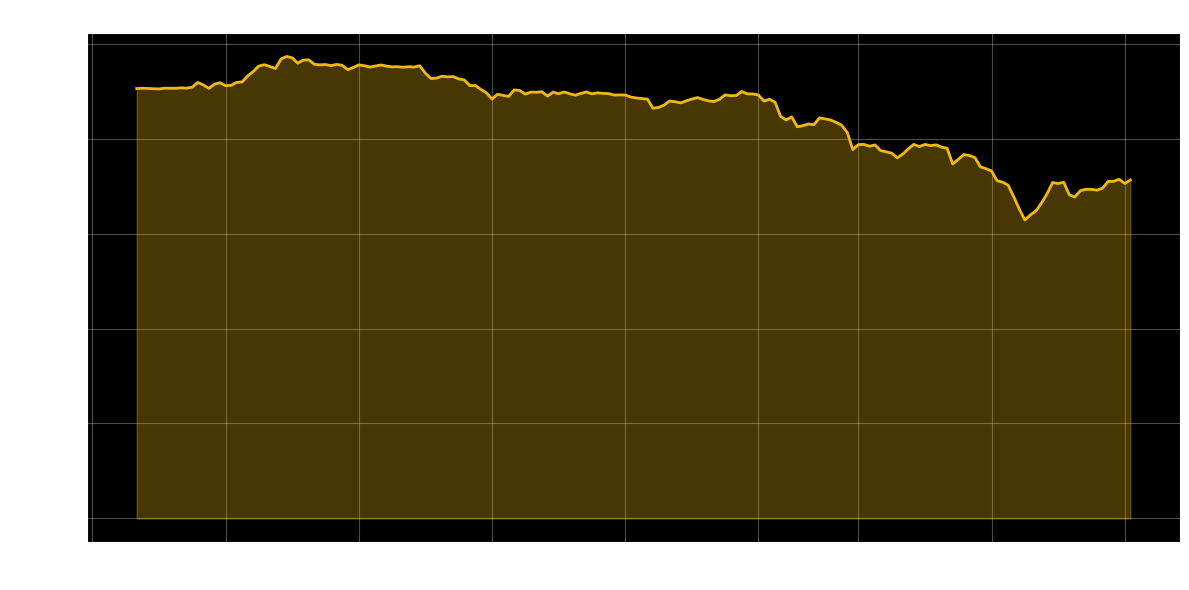

In [ ]:
# Simple line plot of closing prices
plt.figure(figsize=(12, 6))
plt.style.use('dark_background')
plt.plot(df_btc.index, df_btc['close'], color='#F0B90B', linewidth=2) #plot(eje_x,eje_y,color,ancho_linea)
plt.fill_between(df_btc.index, df_btc['close'], alpha=0.3, color='#F0B90B')
plt.title('Bitcoin - Precio de Cierre (30 días)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.7 Gráfico de Velas (Candlestick)

El gráfico de velas japonesas es la visualización más utilizada en trading. Cada vela muestra:
- **Open**: Precio de apertura
- **High**: Precio máximo
- **Low**: Precio mínimo
- **Close**: Precio de cierre

Las velas verdes indican que el precio subió (close > open), las rojas que bajó (close < open).

In [ ]:
df = df_btc.reset_index()

fig = go.Figure(data=[go.Candlestick(x=df['timestamp'],
                open=df['open'], high=df['high'],
                low=df['low'], close=df['close'])
                      ])

fig.update_layout(
    template='plotly_dark',
    title=dict(text='Bitcoin precio 30 dias'),
    yaxis=dict(
      title=dict(
        text='Precio USD'
        )
    )
)

fig.show()

---

## 6. Ejercicio Guiado


---
🎯 EJERCICIO: Obtener Precio de BTC, ETH y SOL

---

Objetivo: Obtener el precio actual de las tres principales criptomonedas
          y mostrarlos de forma formateada

Pasos:
1. Usar cg.get_price() para obtener precios de bitcoin, ethereum, solana
2. Extraer el precio en USD de cada una
3. Mostrar los precios formateados

Hints:
- Los ids se pasan separados por comas: 'bitcoin,ethereum,solana'
- vs_currencies puede ser 'usd' o 'usd,mxn' para múltiples monedas
- Accede a los datos con: data['bitcoin']['usd']
- Documentación de pycoingecko: https://github.com/man-c/pycoingecko

---


In [ ]:
# Your client instance
cg = CoinGeckoAPI()

In [ ]:
# Your code here:
exercise_data = cg.get_price(ids='bitcoin,ethereum,solana', vs_currencies='usd')

In [ ]:
# Display formatted prices
btc_price = exercise_data['bitcoin']['usd']
eth_price = exercise_data['ethereum']['usd']
sol_price = exercise_data['solana']['usd']
print(f'Bitcoin: ${btc_price:,.2f}')
print(f'Ethereum: ${eth_price:,.2f}')
print(f'Solana: ${sol_price:,.2f}')

Bitcoin: $70,939.00
Ethereum: $2,090.03
Solana: $86.97


### Solución

In [ ]:
#@title Haz clic para ver la solucion { display-mode: "form" }
#@markdown > **Nota:** Intenta resolver el ejercicio antes de ver esta solución.
# =============================================================================
# ✅ SOLUCIÓN
# =============================================================================

# Step 1: Get prices for the three main cryptocurrencies
crypto_data = cg.get_price(
    ids='bitcoin,ethereum,solana',
    vs_currencies='usd'
)

# Step 2: Extract individual prices
btc_price = crypto_data['bitcoin']['usd']
eth_price = crypto_data['ethereum']['usd']
sol_price = crypto_data['solana']['usd']

# Step 3: Display formatted prices
print("=" * 40)
print("💰 PRECIOS ACTUALES DE CRIPTOMONEDAS")
print("=" * 40)
print(f"Bitcoin (BTC):  ${btc_price:>12,.2f}")
print(f"Ethereum (ETH): ${eth_price:>12,.2f}")
print(f"Solana (SOL):   ${sol_price:>12,.2f}")
print("=" * 40)

💰 PRECIOS ACTUALES DE CRIPTOMONEDAS
Bitcoin (BTC):  $   70,939.00
Ethereum (ETH): $    2,090.03
Solana (SOL):   $       86.97


---

## 7. Ejercicio Independiente


---
💪 EJERCICIO INDEPENDIENTE: Análisis de Múltiples Criptomonedas

---

Instrucciones: Crea un programa que:
Requisitos:
- [ ] Obtén los precios de 5 criptomonedas diferentes (a tu elección)
- [ ] Muestra los precios en USD y MXN
- [ ] Crea un DataFrame con los datos
- [ ] Identifica cuál es la más cara y la más barata

Bonus (opcional):
- [ ] Crea un gráfico de barras comparando los precios en USD
---


In [ ]:
# Obteniendo lista de criptos
import random

randoms_coins = []
coin_list = cg.get_coins_list()

# Seleccionando un elemento aleatorio
for i in range(5):
  random_coin = random.choice(coin_list)
  randoms_coins.append(random_coin)
  print(f"Criptomoneda aleatoria seleccionada: {random_coin['name']} ({random_coin['symbol']})")

Criptomoneda aleatoria seleccionada: Dolphin (dphn)
Criptomoneda aleatoria seleccionada: Dealer Node (dnode)
Criptomoneda aleatoria seleccionada: Lisk Bridged Wrapped Bitcoin (Lisk) (wbtc)
Criptomoneda aleatoria seleccionada: Rubicon (rubi)
Criptomoneda aleatoria seleccionada: Blunt (blunt)


In [ ]:
# Obteniendo precios de las monedas
coins_ids = [coin['id'] for coin in randoms_coins]
coin_data = cg.get_price(ids=coins_ids, vs_currencies='usd,mxn')
df = pd.DataFrame(coin_data).T # Transponer para que 'usd' y 'mxn' sean columnas

# Convertir las columnas de precio a tipo numérico
df[['usd', 'mxn']] = df[['usd', 'mxn']].astype(float)

df.sort_values(by='usd', ascending=False, inplace=True)

print(df.to_markdown())

print(f'Coin mas cara: {df.index[0]}')
print(f'Coin mas barata: {df.index[-1]}')

|                        |            usd |         mxn |
|:-----------------------|---------------:|------------:|
| lisk-bridged-wbtc-lisk | 71050          | 1.22573e+06 |
| dolphin-2              |     0.00920641 | 0.158936    |
| rubicon                |     0.00017346 | 0.00299253  |
| dealer-node            |     5.978e-05  | 0.00103139  |
| blunt                  |     2.96e-06   | 5.116e-05   |
Coin mas cara: lisk-bridged-wbtc-lisk
Coin mas barata: blunt


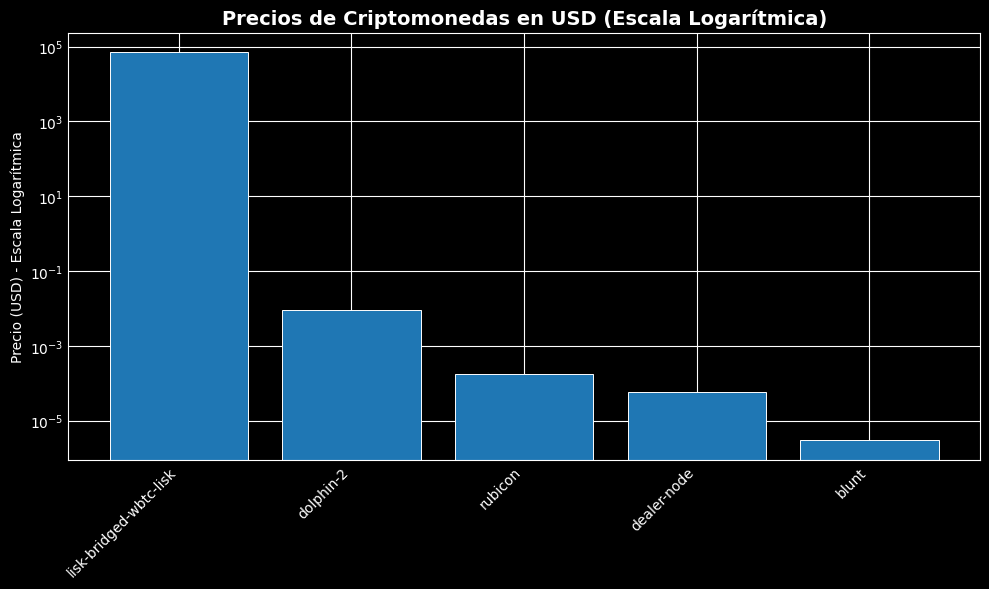

In [ ]:
# Creando grafico
plt.style.use('_mpl-gallery')

# make data:
x = df.index
y = df['usd']

# plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x, y, width=0.8, edgecolor="white", linewidth=0.7)

ax.set_title('Precios de Criptomonedas en USD (Escala Logarítmica)', fontsize=14, fontweight='bold')
ax.set_ylabel('Precio (USD) - Escala Logarítmica')

# Aplicar escala logarítmica al eje Y
ax.set_yscale('log')

# Rotate x-axis labels for better readability if names are long
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

---

## 8. Resumen

### ¿Qué aprendimos hoy?

- **Google Colab/Jupyter**: Cómo usar notebooks para ejecutar código interactivamente
- **Python Fundamentals**: Tipos de datos, estructuras (listas, diccionarios), loops
- **APIs de Crypto**: Qué son y cómo conectarnos a CoinGecko
- **Obtención de datos**: Precios actuales y datos OHLC históricos
- **DataFrames**: Cómo transformar datos de API a estructuras tabulares

### Funciones clave que usamos:

```python
# Inicializar cliente
cg = CoinGeckoAPI()

# Obtener precios actuales
cg.get_price(ids='bitcoin', vs_currencies='usd')

# Obtener datos OHLC
cg.get_coin_ohlc_by_id(id='bitcoin', vs_currency='usd', days='30')
```

---

### Recursos Adicionales

- [Documentación de CoinGecko API](https://www.coingecko.com/en/api/documentation)
- [Documentación de pycoingecko](https://github.com/man-c/pycoingecko)
- [Documentación de Binance.US API](https://docs.binance.us/)
- [Documentación de Pandas](https://pandas.pydata.org/docs/)
- [Tutorial de Python](https://docs.python.org/es/3/tutorial/)